<a href="https://colab.research.google.com/github/Zafar488/flyrank-ml-internship/blob/main/work/notebooks/w07_action_playbook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<a href="https://colab.research.google.com/github/Zafar488/flyrank-ml-internship/blob/main/work/notebooks/w07_action_playbook.ipynb" target="_parent">
<img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

# ML-10 — Content Action Playbook

**Lane:** Refresh / Content Opportunity Scoring  
**Unit of analysis:** One anonymised content page for one anonymised client  
**Primary ranking metric:** Precision@50  
**Validated model:** Logistic Regression  
**Validation design:** Grouped client holdout  
**Feature window:** March 1–15, 2026  
**Outcome window:** March 16–31, 2026  
**Intended use:** Human decision-support for content-review prioritisation

This notebook turns the validated ML-09 output into a practical, non-production action playbook.

It:

- reconstructs the frozen ML-09 grouped model configuration;
- uses the same `SEED=42` and `TEST_SIZE=0.25`;
- derives action thresholds from training rows only;
- creates ranked actions, archetypes, reason codes, confidence notes, and review-effort assumptions;
- explains the refresh/decay insight and its limits;
- defines intended use, human-review rules, no-go cases, and monitoring triggers;
- exports the queues, receipts, figures, and fitted pipeline used by the research paper.

The model score is not a final editorial decision. It is one measured input into a human-reviewed queue.

## 0. Setup

Store a Hugging Face **Read** token in Google Colab Secrets using the name `HF_TOKEN`.

This notebook is standalone. It does not execute another notebook with `%run`.

The queue CSV files stay out of Git by design. Commit the notebook, aggregate JSON receipts, and reusable figures.

In [1]:
%pip install -q duckdb huggingface_hub scikit-learn pandas numpy matplotlib joblib

In [2]:
from __future__ import annotations

import json
import os
import subprocess
from pathlib import Path
from typing import Any

import duckdb
import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from google.colab import userdata
from huggingface_hub import whoami

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    average_precision_score,
    roc_auc_score,
)
from sklearn.model_selection import GroupShuffleSplit
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler,
)


# ============================================================
# REPRODUCIBILITY — MATCHES ML-08 / ML-09
# ============================================================

SEED = 42
TEST_SIZE = 0.25
TOP_K = 50
MIN_ARCHETYPE_N = 30

FEATURE_START = "2026-03-01"
FEATURE_END = "2026-03-15"
OUTCOME_START = "2026-03-16"
OUTCOME_END = "2026-03-31"

np.random.seed(SEED)


# ============================================================
# FROZEN PLAYBOOK POLICY
# ============================================================

HIGH_RISK_THRESHOLD = 0.60
BORDERLINE_LOW = 0.45
BORDERLINE_HIGH = 0.60
LOW_RISK_THRESHOLD = 0.35

MIN_ACTION_ACTIVE_DAYS = 8
MIN_ACTION_AVAILABLE_DAYS = 8

MODEL_SCORE_WEIGHT = 0.65
VISIBILITY_VALUE_WEIGHT = 0.25
DATA_QUALITY_WEIGHT = 0.10

assert np.isclose(
    MODEL_SCORE_WEIGHT
    + VISIBILITY_VALUE_WEIGHT
    + DATA_QUALITY_WEIGHT,
    1.0,
)


# ============================================================
# REPOSITORY
# ============================================================

REPO_URL = "https://github.com/Zafar488/flyrank-ml-internship"
REPO_DIR = "flyrank-ml-internship"

current_directory = Path.cwd()

if current_directory.name == REPO_DIR:
    REPO_ROOT = current_directory
else:
    REPO_ROOT = Path("/content") / REPO_DIR

    if not REPO_ROOT.exists():
        print("Repository not found. Cloning repository...")

        subprocess.run(
            [
                "git",
                "clone",
                "--depth",
                "1",
                REPO_URL,
                str(REPO_ROOT),
            ],
            check=True,
        )

    os.chdir(REPO_ROOT)


# ============================================================
# OUTPUT PATHS
# ============================================================

OUTPUT_DIR = Path("work/outputs")
FIGURE_DIR = Path("work/figures")
MODEL_DIR = OUTPUT_DIR / "models"

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DIR.mkdir(parents=True, exist_ok=True)

FULL_QUEUE_PATH = (
    OUTPUT_DIR
    / "content_action_playbook_queue.csv"
)

ACTIONABLE_QUEUE_PATH = (
    OUTPUT_DIR
    / "content_action_playbook_actionable_queue.csv"
)

TOP_50_PATH = (
    OUTPUT_DIR
    / "content_action_playbook_top_50.csv"
)

ACTION_VALIDATION_PATH = (
    OUTPUT_DIR
    / "content_action_archetype_validation.csv"
)

CAPACITY_PATH = (
    OUTPUT_DIR
    / "content_action_capacity_summary.csv"
)

CAPACITY_SCENARIOS_PATH = (
    OUTPUT_DIR
    / "content_action_capacity_scenarios.csv"
)

METRICS_PATH = (
    OUTPUT_DIR
    / "content_action_playbook_metrics.json"
)

PLAYBOOK_PATH = (
    OUTPUT_DIR
    / "content_action_playbook.json"
)

MONITORING_PATH = (
    OUTPUT_DIR
    / "content_action_monitoring_triggers.json"
)

HUMAN_REVIEW_PATH = (
    OUTPUT_DIR
    / "content_action_human_review.json"
)

MODEL_PATH = (
    MODEL_DIR
    / "ml10_grouped_action_playbook_model.joblib"
)


# ============================================================
# HUGGING FACE AUTHENTICATION
# ============================================================

HF_TOKEN = userdata.get("HF_TOKEN")

if not HF_TOKEN:
    raise ValueError(
        "HF_TOKEN was not found. Add a Hugging Face Read token "
        "to Colab Secrets and enable notebook access."
    )

hf_user = whoami(token=HF_TOKEN)

print(
    "Hugging Face authentication successful:",
    hf_user.get("name", "authenticated-user"),
)


# ============================================================
# DUCKDB
# ============================================================

con = duckdb.connect()

safe_token = HF_TOKEN.replace("'", "''")

con.execute(
    f"""
    CREATE OR REPLACE SECRET hf (
        TYPE huggingface,
        TOKEN '{safe_token}'
    )
    """
)

WAREHOUSE_ROOT = "hf://datasets/FlyRank/internship-warehouse"

MARCH_FACT = (
    "read_parquet("
    f"'{WAREHOUSE_ROOT}/fact_content_daily_performance/"
    "month=2026-03/*.parquet'"
    ")"
)

print("Repository root:", Path.cwd())
print("Output directory:", OUTPUT_DIR)
print("Figure directory:", FIGURE_DIR)
print("Feature window:", FEATURE_START, "to", FEATURE_END)
print("Outcome window:", OUTCOME_START, "to", OUTCOME_END)
print("Frozen test size:", TEST_SIZE)

Repository not found. Cloning repository...
Hugging Face authentication successful: zafar4050
Repository root: /content/flyrank-ml-internship
Output directory: work/outputs
Figure directory: work/figures
Feature window: 2026-03-01 to 2026-03-15
Outcome window: 2026-03-16 to 2026-03-31
Frozen test size: 0.25


## 1. Ranked Actions and Reason Codes

The validated Logistic Regression probability is converted into a ranked human-review queue.

The playbook combines only prediction-time information:

- measured model score;
- visibility-value percentile;
- feature-window data quality;
- position-adjusted CTR context;
- average position;
- position volatility;
- active and available feature-window days.

The retrospective outcome proxy is used only after action assignment to audit how the action groups behaved. It is never an action input.

### Archetype → Action Mapping

| Archetype | Action | Human meaning |
|---|---|---|
| Limited evidence | `MONITOR` | Collect more evidence before acting |
| High visibility with weak CTR | `CTR_REVIEW` | Review title, snippet, intent, and SERP context |
| Valuable Page-2 opportunity | `EXPAND_AND_OPTIMISE` | Review coverage and ranking opportunity |
| High measured risk with volatility | `REFRESH_REVIEW` | Inspect freshness, quality, intent, and technical changes |
| High measured risk with stable Page-1 visibility | `REFRESH_AND_PROTECT` | Review conservatively and protect existing visibility |
| Low-risk high-value page | `PROTECT` | Avoid unnecessary changes |
| High risk without a clear archetype | `MANUAL_REVIEW` | Conduct a full human investigation |
| Borderline measured risk | `MONITOR` | Schedule a later review |
| Lower measured priority | `NO_IMMEDIATE_ACTION` | Keep in the monitoring population |

### Priority Score

The fixed review-order heuristic is:

- 65% model score;
- 25% visibility-value percentile;
- 10% data-quality proxy.

It is not a monetary return estimate and does not prove that an action will improve performance.

In [3]:
# ============================================================
# VERIFY THE SOURCE PARTITION
# ============================================================

source_check = con.sql(
    f"""
    SELECT
        COUNT(*) AS total_rows,
        MIN(report_date) AS minimum_date,
        MAX(report_date) AS maximum_date,
        COUNT(DISTINCT client_hash_id) AS unique_clients,
        COUNT(
            DISTINCT (
                client_hash_id,
                content_hash_id
            )
        ) AS unique_client_pages
    FROM {MARCH_FACT}
    """
).df()

display(source_check)

minimum_date = pd.to_datetime(
    source_check.loc[0, "minimum_date"]
).date()

maximum_date = pd.to_datetime(
    source_check.loc[0, "maximum_date"]
).date()

assert str(minimum_date) == FEATURE_START
assert str(maximum_date) == OUTCOME_END

print("March 2026 source verification passed.")


# ============================================================
# BUILD ONE ROW PER ANONYMISED CLIENT-PAGE
# ============================================================

page_frame = con.sql(
    f"""
    SELECT
        client_hash_id,
        content_hash_id,

        SUM(
            CASE
                WHEN report_date BETWEEN
                     DATE '{FEATURE_START}'
                     AND DATE '{FEATURE_END}'
                 AND gsc_data_available IS TRUE
                THEN COALESCE(gsc_impressions, 0)
                ELSE 0
            END
        ) AS feature_impressions,

        SUM(
            CASE
                WHEN report_date BETWEEN
                     DATE '{FEATURE_START}'
                     AND DATE '{FEATURE_END}'
                 AND gsc_data_available IS TRUE
                THEN COALESCE(gsc_clicks, 0)
                ELSE 0
            END
        ) AS feature_clicks,

        AVG(
            CASE
                WHEN report_date BETWEEN
                     DATE '{FEATURE_START}'
                     AND DATE '{FEATURE_END}'
                 AND gsc_data_available IS TRUE
                THEN gsc_avg_position
            END
        ) AS feature_avg_position,

        STDDEV_SAMP(
            CASE
                WHEN report_date BETWEEN
                     DATE '{FEATURE_START}'
                     AND DATE '{FEATURE_END}'
                 AND gsc_data_available IS TRUE
                THEN gsc_avg_position
            END
        ) AS feature_position_volatility,

        COUNT(
            DISTINCT CASE
                WHEN report_date BETWEEN
                     DATE '{FEATURE_START}'
                     AND DATE '{FEATURE_END}'
                 AND gsc_data_available IS TRUE
                 AND COALESCE(gsc_impressions, 0) > 0
                THEN report_date
            END
        ) AS feature_active_days,

        COUNT(
            DISTINCT CASE
                WHEN report_date BETWEEN
                     DATE '{FEATURE_START}'
                     AND DATE '{FEATURE_END}'
                 AND gsc_data_available IS TRUE
                THEN report_date
            END
        ) AS feature_available_days,

        SUM(
            CASE
                WHEN report_date BETWEEN
                     DATE '{OUTCOME_START}'
                     AND DATE '{OUTCOME_END}'
                 AND gsc_data_available IS TRUE
                THEN COALESCE(gsc_impressions, 0)
                ELSE 0
            END
        ) AS outcome_impressions,

        COUNT(
            DISTINCT CASE
                WHEN report_date BETWEEN
                     DATE '{OUTCOME_START}'
                     AND DATE '{OUTCOME_END}'
                 AND gsc_data_available IS TRUE
                THEN report_date
            END
        ) AS outcome_available_days

    FROM {MARCH_FACT}

    GROUP BY
        client_hash_id,
        content_hash_id
    """
).df()

duplicate_rows = int(
    page_frame.duplicated(
        subset=[
            "client_hash_id",
            "content_hash_id",
        ]
    ).sum()
)

print("Raw page rows:", f"{len(page_frame):,}")
print("Duplicate client-page rows:", duplicate_rows)

assert duplicate_rows == 0

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,total_rows,minimum_date,maximum_date,unique_clients,unique_client_pages
0,9841378,2026-03-01,2026-03-31,55,331437


March 2026 source verification passed.


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Raw page rows: 331,437
Duplicate client-page rows: 0


In [4]:
# ============================================================
# SAFE FEATURE ENGINEERING
# ============================================================

page_frame["feature_ctr"] = np.where(
    page_frame["feature_impressions"] > 0,
    (
        page_frame["feature_clicks"]
        / page_frame["feature_impressions"]
    ),
    np.nan,
)

page_frame["feature_daily_impressions"] = np.where(
    page_frame["feature_available_days"] > 0,
    (
        page_frame["feature_impressions"]
        / page_frame["feature_available_days"]
    ),
    np.nan,
)

page_frame["outcome_daily_impressions"] = np.where(
    page_frame["outcome_available_days"] > 0,
    (
        page_frame["outcome_impressions"]
        / page_frame["outcome_available_days"]
    ),
    np.nan,
)

page_frame["is_declining_proxy"] = (
    page_frame["outcome_daily_impressions"]
    <
    0.80
    * page_frame["feature_daily_impressions"]
).astype(int)

page_frame["log_feature_impressions"] = np.log1p(
    page_frame["feature_impressions"]
)

page_frame["position_band"] = pd.cut(
    page_frame["feature_avg_position"],
    bins=[
        0,
        3,
        10,
        20,
    ],
    labels=[
        "Top 3",
        "Page 1",
        "Page 2",
    ],
    include_lowest=True,
)

page_frame["position_band"] = (
    page_frame["position_band"]
    .astype("object")
)


# ============================================================
# SAME RETROSPECTIVE EVALUATION POPULATION AS ML-08 / ML-09
# ============================================================

model_frame = page_frame[
    (page_frame["feature_impressions"] >= 500)
    & (page_frame["feature_available_days"] >= 5)
    & (page_frame["outcome_available_days"] >= 5)
    & (page_frame["feature_avg_position"] > 0)
    & (page_frame["feature_avg_position"] <= 20)
    & (page_frame["feature_ctr"].notna())
    & (page_frame["position_band"].notna())
].copy()

model_frame = (
    model_frame
    .drop_duplicates(
        subset=[
            "client_hash_id",
            "content_hash_id",
        ]
    )
    .reset_index(drop=True)
)

numeric_features = [
    "log_feature_impressions",
    "feature_clicks",
    "feature_ctr",
    "feature_avg_position",
    "feature_active_days",
    "feature_position_volatility",
]

categorical_features = [
    "position_band",
]

feature_columns = (
    numeric_features
    + categorical_features
)

target_column = "is_declining_proxy"
group_column = "client_hash_id"

print(
    "Retrospective evaluation rows:",
    f"{len(model_frame):,}",
)

print(
    "Observed positive base rate:",
    round(model_frame[target_column].mean(), 3),
)

print(
    "Anonymised clients:",
    model_frame[group_column].nunique(),
)

assert len(model_frame) > TOP_K
assert len(feature_columns) == 7
assert target_column not in feature_columns
assert group_column not in feature_columns
assert "content_hash_id" not in feature_columns
assert "outcome_impressions" not in feature_columns
assert "outcome_daily_impressions" not in feature_columns

Retrospective evaluation rows: 34,038
Observed positive base rate: 0.309
Anonymised clients: 32


In [5]:
# ============================================================
# TRAINING-ONLY PREPROCESSING AND FROZEN MODEL
# ============================================================

numeric_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median"),
        ),
        (
            "scaler",
            StandardScaler(),
        ),
    ]
)

categorical_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="most_frequent"
            ),
        ),
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore"
            ),
        ),
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            numeric_pipeline,
            numeric_features,
        ),
        (
            "categorical",
            categorical_pipeline,
            categorical_features,
        ),
    ],
    remainder="drop",
)


def build_model() -> Pipeline:
    return Pipeline(
        steps=[
            (
                "preprocessor",
                clone(preprocessor),
            ),
            (
                "model",
                LogisticRegression(
                    max_iter=2000,
                    class_weight="balanced",
                    random_state=SEED,
                ),
            ),
        ]
    )


def precision_at_k(
    labels: Any,
    scores: Any,
    k: int = TOP_K,
) -> float:
    labels_array = np.asarray(
        labels,
        dtype=int,
    )

    scores_array = np.asarray(
        scores,
        dtype=float,
    )

    if len(labels_array) != len(scores_array):
        raise ValueError(
            "Labels and scores must have equal length."
        )

    if len(labels_array) == 0:
        raise ValueError(
            "Evaluation arrays cannot be empty."
        )

    if not np.isfinite(scores_array).all():
        raise ValueError(
            "Scores contain NaN or infinite values."
        )

    effective_k = min(
        k,
        len(labels_array),
    )

    ranked_indices = np.argsort(
        -scores_array,
        kind="mergesort",
    )[:effective_k]

    return float(
        labels_array[ranked_indices].mean()
    )


def percentile_from_reference(
    reference_values: Any,
    new_values: Any,
) -> np.ndarray:
    reference_array = np.asarray(
        reference_values,
        dtype=float,
    )

    new_array = np.asarray(
        new_values,
        dtype=float,
    )

    reference_array = np.sort(
        reference_array[
            np.isfinite(reference_array)
        ]
    )

    if len(reference_array) == 0:
        raise ValueError(
            "Reference distribution cannot be empty."
        )

    return (
        np.searchsorted(
            reference_array,
            new_array,
            side="right",
        )
        / len(reference_array)
    )


group_splitter = GroupShuffleSplit(
    n_splits=1,
    test_size=TEST_SIZE,
    random_state=SEED,
)

train_indices, validation_indices = next(
    group_splitter.split(
        model_frame[feature_columns],
        model_frame[target_column],
        groups=model_frame[group_column],
    )
)

train_frame = (
    model_frame
    .iloc[train_indices]
    .copy()
    .reset_index(drop=True)
)

validation_frame = (
    model_frame
    .iloc[validation_indices]
    .copy()
    .reset_index(drop=True)
)

train_clients = set(
    train_frame[group_column].unique()
)

validation_clients = set(
    validation_frame[group_column].unique()
)

client_overlap = len(
    train_clients.intersection(
        validation_clients
    )
)

assert client_overlap == 0

playbook_model = build_model()

playbook_model.fit(
    train_frame[feature_columns],
    train_frame[target_column],
)

validation_scores = (
    playbook_model
    .predict_proba(
        validation_frame[feature_columns]
    )[:, 1]
)

validation_labels = (
    validation_frame[target_column]
    .to_numpy(dtype=int)
)

grouped_precision_50 = precision_at_k(
    validation_labels,
    validation_scores,
    TOP_K,
)

grouped_average_precision = float(
    average_precision_score(
        validation_labels,
        validation_scores,
    )
)

grouped_roc_auc = float(
    roc_auc_score(
        validation_labels,
        validation_scores,
    )
)

validation_base_rate = float(
    validation_labels.mean()
)

print("Training rows:", f"{len(train_frame):,}")
print("Validation rows:", f"{len(validation_frame):,}")
print("Training clients:", len(train_clients))
print("Validation clients:", len(validation_clients))
print("Grouped client overlap:", client_overlap)
print(
    "Validation base rate:",
    round(validation_base_rate, 4),
)
print(
    "Grouped Precision@50:",
    round(grouped_precision_50, 4),
)
print(
    "Grouped Average Precision:",
    round(grouped_average_precision, 4),
)
print(
    "Grouped ROC-AUC:",
    round(grouped_roc_auc, 4),
)

Training rows: 18,075
Validation rows: 15,963
Training clients: 24
Validation clients: 8
Grouped client overlap: 0
Validation base rate: 0.3008
Grouped Precision@50: 0.64
Grouped Average Precision: 0.3939
Grouped ROC-AUC: 0.6175


### Training-Referenced Archetype Thresholds

To avoid adapting the playbook to the validation population, the following references are calculated from training rows only:

- median CTR within each position band;
- 75th-percentile impressions;
- median and 75th-percentile position volatility;
- the visibility percentile reference distribution;
- the imputation fallback for action-policy volatility.

The fixed risk thresholds and score weights are policy choices, not fitted outcome optimisations.

The validation outcome is used only after action assignment to produce an observational action-group audit.

In [6]:
# ============================================================
# TRAINING-ONLY POLICY REFERENCES
# ============================================================

train_policy = train_frame.copy()
validation_queue = validation_frame.copy()

train_policy["position_band_text"] = (
    train_policy["position_band"]
    .astype(str)
)

validation_queue["position_band_text"] = (
    validation_queue["position_band"]
    .astype(str)
)

training_position_ctr_medians = (
    train_policy
    .groupby(
        "position_band_text",
        observed=True,
    )["feature_ctr"]
    .median()
    .to_dict()
)

global_training_ctr = float(
    train_policy["feature_ctr"].median()
)

training_impression_q75 = float(
    train_policy["feature_impressions"]
    .quantile(0.75)
)

training_volatility_median = float(
    train_policy["feature_position_volatility"]
    .median()
)

if not np.isfinite(training_volatility_median):
    training_volatility_median = 0.0

training_volatility_q75 = float(
    train_policy["feature_position_volatility"]
    .fillna(training_volatility_median)
    .quantile(0.75)
)

validation_queue["model_score"] = np.asarray(
    validation_scores,
    dtype=float,
)

validation_queue["position_band_ctr_median"] = (
    validation_queue["position_band_text"]
    .map(training_position_ctr_medians)
    .astype(float)
    .fillna(global_training_ctr)
)

validation_queue["policy_volatility"] = (
    validation_queue["feature_position_volatility"]
    .fillna(training_volatility_median)
)

validation_queue["visibility_value_proxy"] = (
    percentile_from_reference(
        train_policy["feature_impressions"],
        validation_queue["feature_impressions"],
    )
)

validation_queue["data_quality_proxy"] = (
    (
        validation_queue["feature_active_days"]
        .clip(0, 15)
        / 15.0
    )
    +
    (
        validation_queue["feature_available_days"]
        .clip(0, 15)
        / 15.0
    )
) / 2.0

validation_queue["review_priority_score"] = (
    100.0
    * (
        MODEL_SCORE_WEIGHT
        * validation_queue["model_score"]
        +
        VISIBILITY_VALUE_WEIGHT
        * validation_queue[
            "visibility_value_proxy"
        ]
        +
        DATA_QUALITY_WEIGHT
        * validation_queue[
            "data_quality_proxy"
        ]
    )
).round(2)

policy_reference_receipt = pd.DataFrame(
    [
        {
            "reference_population": "training only",
            "training_impression_q75": (
                training_impression_q75
            ),
            "training_volatility_median": (
                training_volatility_median
            ),
            "training_volatility_q75": (
                training_volatility_q75
            ),
            "high_risk_threshold": (
                HIGH_RISK_THRESHOLD
            ),
            "borderline_low": (
                BORDERLINE_LOW
            ),
            "borderline_high": (
                BORDERLINE_HIGH
            ),
            "low_risk_threshold": (
                LOW_RISK_THRESHOLD
            ),
        }
    ]
)

display(policy_reference_receipt)

print(
    "Training position-band CTR medians:",
    training_position_ctr_medians,
)

,reference_population,training_impression_q75,training_volatility_median,training_volatility_q75,high_risk_threshold,borderline_low,borderline_high,low_risk_threshold
0,training only,2556.0,1.649278,3.401006,0.6,0.45,0.6,0.35


Training position-band CTR medians: {'Page 1': 0.002103049421661409, 'Page 2': 0.003121748178980229, 'Top 3': 0.0027447392497712718}


In [7]:
# ============================================================
# ACTION MAPPING — PRE-OUTCOME INPUTS ONLY
# ============================================================

ACTION_INPUT_COLUMNS = {
    "model_score",
    "feature_impressions",
    "feature_ctr",
    "feature_avg_position",
    "feature_active_days",
    "feature_available_days",
    "policy_volatility",
    "position_band_text",
    "position_band_ctr_median",
    "visibility_value_proxy",
    "data_quality_proxy",
    "review_priority_score",
}

FORBIDDEN_ACTION_INPUTS = {
    "outcome_impressions",
    "outcome_daily_impressions",
    "outcome_available_days",
    "is_declining_proxy",
    "client_hash_id",
    "content_hash_id",
    "trend_direction",
    "trend_pct",
    "decline_ratio",
    "health_score",
    "priority_score",
    "needs_ctr_fix",
    "refresh_flag",
}

assert ACTION_INPUT_COLUMNS.isdisjoint(
    FORBIDDEN_ACTION_INPUTS
)


def classify_playbook_row(
    row: pd.Series,
) -> pd.Series:
    score = float(row["model_score"])
    impressions = float(
        row["feature_impressions"]
    )
    ctr = float(row["feature_ctr"])
    position = float(
        row["feature_avg_position"]
    )
    volatility = float(
        row["policy_volatility"]
    )
    ctr_reference = float(
        row["position_band_ctr_median"]
    )
    active_days = int(
        row["feature_active_days"]
    )
    available_days = int(
        row["feature_available_days"]
    )

    limited_evidence = (
        active_days < MIN_ACTION_ACTIVE_DAYS
        or
        available_days < MIN_ACTION_AVAILABLE_DAYS
    )

    high_visibility = (
        impressions >= training_impression_q75
    )

    weak_ctr = (
        ctr < ctr_reference
    )

    high_volatility = (
        volatility >= training_volatility_q75
    )

    stable_volatility = (
        volatility <= training_volatility_median
    )

    if (
        limited_evidence
        and
        score >= BORDERLINE_LOW
    ):
        archetype = "LIMITED_EVIDENCE"
        action = "MONITOR"
        reason_code = "LIMITED_FEATURE_HISTORY"
        confidence_level = "LOW"
        confidence_note = (
            "The measured score is not sufficient for an "
            "action recommendation because feature-window "
            "evidence is limited."
        )

    elif (
        score >= HIGH_RISK_THRESHOLD
        and
        position <= 10
        and
        high_visibility
        and
        weak_ctr
    ):
        archetype = "HIGH_VISIBILITY_WEAK_CTR"
        action = "CTR_REVIEW"
        reason_code = "CTR_GAP_HIGH_VISIBILITY"
        confidence_level = "HIGH"
        confidence_note = (
            "High measured risk, high training-referenced "
            "visibility, and CTR below the training reference "
            "for the same position band."
        )

    elif (
        score >= HIGH_RISK_THRESHOLD
        and
        10 < position <= 20
        and
        high_visibility
    ):
        archetype = "VALUABLE_PAGE_2_OPPORTUNITY"
        action = "EXPAND_AND_OPTIMISE"
        reason_code = "HIGH_VALUE_PAGE_2"
        confidence_level = "MEDIUM"
        confidence_note = (
            "High measured risk and strong visibility in the "
            "Page-2 position range. Coverage and intent require "
            "human inspection."
        )

    elif (
        score >= HIGH_RISK_THRESHOLD
        and
        high_volatility
    ):
        archetype = "HIGH_RISK_VOLATILE"
        action = "REFRESH_REVIEW"
        reason_code = "HIGH_RISK_HIGH_VOLATILITY"
        confidence_level = "MEDIUM"
        confidence_note = (
            "High measured risk with training-referenced high "
            "position volatility. Freshness is not directly "
            "observed and must be checked by a reviewer."
        )

    elif (
        score >= HIGH_RISK_THRESHOLD
        and
        position <= 10
        and
        stable_volatility
    ):
        archetype = "HIGH_RISK_STABLE_VISIBILITY"
        action = "REFRESH_AND_PROTECT"
        reason_code = "HIGH_RISK_STABLE_PAGE_1"
        confidence_level = "MEDIUM"
        confidence_note = (
            "High measured risk with relatively stable Page-1 "
            "visibility. Any change should protect valuable "
            "sections and include a rollback plan."
        )

    elif (
        score <= LOW_RISK_THRESHOLD
        and
        position <= 10
        and
        high_visibility
    ):
        archetype = "LOW_RISK_HIGH_VALUE"
        action = "PROTECT"
        reason_code = "LOW_RISK_HIGH_VISIBILITY"
        confidence_level = "MEDIUM"
        confidence_note = (
            "Low measured risk with strong current visibility. "
            "Avoid unnecessary edits and monitor."
        )

    elif (
        BORDERLINE_LOW
        <= score
        < BORDERLINE_HIGH
    ):
        archetype = "BORDERLINE_RISK"
        action = "MONITOR"
        reason_code = "BORDERLINE_MEASURED_RISK"
        confidence_level = "LOW"
        confidence_note = (
            "The measured score is borderline. Collect more "
            "evidence before selecting a content action."
        )

    elif score >= HIGH_RISK_THRESHOLD:
        archetype = "HIGH_RISK_OTHER"
        action = "MANUAL_REVIEW"
        reason_code = "HIGH_RISK_NO_CLEAR_ARCHETYPE"
        confidence_level = "LOW"
        confidence_note = (
            "High measured risk without a sufficiently clear "
            "action archetype. A full human investigation is "
            "required."
        )

    else:
        archetype = "LOWER_PRIORITY_OTHER"
        action = "NO_IMMEDIATE_ACTION"
        reason_code = "LOWER_MEASURED_PRIORITY"
        confidence_level = "LOW"
        confidence_note = (
            "The page does not meet the current human-review "
            "thresholds and remains in the monitoring population."
        )

    return pd.Series(
        {
            "archetype": archetype,
            "action_label": action,
            "reason_code": reason_code,
            "confidence_level": confidence_level,
            "confidence_note": confidence_note,
        }
    )


validation_queue[
    [
        "archetype",
        "action_label",
        "reason_code",
        "confidence_level",
        "confidence_note",
    ]
] = validation_queue.apply(
    classify_playbook_row,
    axis=1,
)


# ============================================================
# COST AND VALUE ASSUMPTIONS
# ============================================================

action_cost_map = {
    "CTR_REVIEW": ("LOW", 20),
    "EXPAND_AND_OPTIMISE": ("HIGH", 120),
    "REFRESH_REVIEW": ("MEDIUM", 90),
    "REFRESH_AND_PROTECT": ("MEDIUM", 75),
    "PROTECT": ("LOW", 15),
    "MONITOR": ("LOW", 10),
    "MANUAL_REVIEW": ("MEDIUM", 30),
    "NO_IMMEDIATE_ACTION": ("NONE", 0),
}

validation_queue["review_cost_tier"] = (
    validation_queue["action_label"]
    .map(
        lambda action: action_cost_map[action][0]
    )
)

validation_queue["estimated_review_minutes"] = (
    validation_queue["action_label"]
    .map(
        lambda action: action_cost_map[action][1]
    )
)

validation_queue["value_tier"] = pd.cut(
    validation_queue["visibility_value_proxy"],
    bins=[
        0.0,
        0.50,
        0.80,
        1.0,
    ],
    labels=[
        "STANDARD",
        "MEDIUM",
        "HIGH",
    ],
    include_lowest=True,
)

validation_queue["human_review_required"] = (
    validation_queue["action_label"]
    .ne("NO_IMMEDIATE_ACTION")
)

full_queue = (
    validation_queue
    .sort_values(
        [
            "review_priority_score",
            "model_score",
            "feature_impressions",
        ],
        ascending=[
            False,
            False,
            False,
        ],
        kind="mergesort",
    )
    .reset_index(drop=True)
)

full_queue.insert(
    0,
    "rank",
    np.arange(
        1,
        len(full_queue) + 1,
    ),
)

actionable_queue = (
    full_queue[
        full_queue["human_review_required"]
    ]
    .copy()
    .reset_index(drop=True)
)

actionable_queue["actionable_rank"] = np.arange(
    1,
    len(actionable_queue) + 1,
)

actionable_queue["review_batch"] = pd.cut(
    actionable_queue["actionable_rank"],
    bins=[
        0,
        50,
        200,
        np.inf,
    ],
    labels=[
        "NOW_TOP_50",
        "NEXT_150",
        "BACKLOG",
    ],
)

top_50_actionable = (
    actionable_queue
    .head(TOP_K)
    .copy()
)

public_queue_columns = [
    "actionable_rank",
    "review_batch",
    "review_priority_score",
    "model_score",
    "action_label",
    "reason_code",
    "archetype",
    "confidence_level",
    "value_tier",
    "review_cost_tier",
    "estimated_review_minutes",
    "feature_impressions",
    "feature_ctr",
    "feature_avg_position",
    "policy_volatility",
    "confidence_note",
]

print("All validation rows:", f"{len(full_queue):,}")
print(
    "Actionable review rows:",
    f"{len(actionable_queue):,}",
)
print(
    "No-immediate-action rows:",
    f"{full_queue['action_label'].eq('NO_IMMEDIATE_ACTION').sum():,}",
)

display(
    actionable_queue[
        public_queue_columns
    ]
    .head(25)
    .round(5)
)

All validation rows: 15,963
Actionable review rows: 11,154
No-immediate-action rows: 4,809


,actionable_rank,review_batch,review_priority_score,model_score,action_label,reason_code,archetype,confidence_level,value_tier,review_cost_tier,estimated_review_minutes,feature_impressions,feature_ctr,feature_avg_position,policy_volatility,confidence_note
0,1,NOW_TOP_50,80.56,0.70110,CTR_REVIEW,CTR_GAP_HIGH_VISIBILITY,HIGH_VISIBILITY_WEAK_CTR,HIGH,HIGH,LOW,20,83772.0,0.00000,8.60791,12.40765,"High measured risk, high training-referenced v..."
1,2,NOW_TOP_50,79.14,0.69063,CTR_REVIEW,CTR_GAP_HIGH_VISIBILITY,HIGH_VISIBILITY_WEAK_CTR,HIGH,HIGH,LOW,20,11060.0,0.00009,8.80066,9.04015,"High measured risk, high training-referenced v..."
2,3,NOW_TOP_50,76.71,0.67319,CTR_REVIEW,CTR_GAP_HIGH_VISIBILITY,HIGH_VISIBILITY_WEAK_CTR,HIGH,HIGH,LOW,20,5961.0,0.00134,7.69051,10.75935,"High measured risk, high training-referenced v..."
3,4,NOW_TOP_50,76.52,0.68721,CTR_REVIEW,CTR_GAP_HIGH_VISIBILITY,HIGH_VISIBILITY_WEAK_CTR,HIGH,HIGH,LOW,20,4403.0,0.00068,6.24331,10.99886,"High measured risk, high training-referenced v..."
4,5,NOW_TOP_50,75.66,0.64409,CTR_REVIEW,CTR_GAP_HIGH_VISIBILITY,HIGH_VISIBILITY_WEAK_CTR,HIGH,HIGH,LOW,20,8352.0,0.00060,5.99868,7.42471,"High measured risk, high training-referenced v..."
5,6,NOW_TOP_50,75.34,0.64443,CTR_REVIEW,CTR_GAP_HIGH_VISIBILITY,HIGH_VISIBILITY_WEAK_CTR,HIGH,HIGH,LOW,20,7161.0,0.00056,9.75532,4.54292,"High measured risk, high training-referenced v..."
6,7,NOW_TOP_50,75.29,0.64020,CTR_REVIEW,CTR_GAP_HIGH_VISIBILITY,HIGH_VISIBILITY_WEAK_CTR,HIGH,HIGH,LOW,20,7895.0,0.00013,6.98665,4.97888,"High measured risk, high training-referenced v..."
7,8,NOW_TOP_50,74.79,0.61238,CTR_REVIEW,CTR_GAP_HIGH_VISIBILITY,HIGH_VISIBILITY_WEAK_CTR,HIGH,HIGH,LOW,20,55680.0,0.00027,9.01353,3.76384,"High measured risk, high training-referenced v..."
8,9,NOW_TOP_50,74.57,0.61389,CTR_REVIEW,CTR_GAP_HIGH_VISIBILITY,HIGH_VISIBILITY_WEAK_CTR,HIGH,HIGH,LOW,20,16711.0,0.00000,8.73714,1.80036,"High measured risk, high training-referenced v..."
9,10,NOW_TOP_50,74.56,0.63902,CTR_REVIEW,CTR_GAP_HIGH_VISIBILITY,HIGH_VISIBILITY_WEAK_CTR,HIGH,HIGH,LOW,20,6117.0,0.00049,9.91365,3.53101,"High measured risk, high training-referenced v..."


### Decay / Refresh Insight

The research finding reviewed in ML-09 observed that recently refreshed mature content was associated with stronger measured performance. That comparison was observational and may contain selection bias.

This playbook does **not** directly observe:

- content age;
- days since the last editorial update;
- factual accuracy;
- editorial quality;
- competitor changes;
- query-level intent change;
- the causal effect of a refresh.

Therefore:

- `REFRESH_REVIEW` means **inspect freshness and quality first**;
- `REFRESH_AND_PROTECT` means **review conservatively while protecting existing visibility**;
- neither action means “rewrite automatically.”

A public-safe interpretation is:

> Pages assigned to refresh-review archetypes showed pre-outcome patterns associated with the later decline proxy in this grouped holdout and may deserve earlier human inspection. This does not prove that refreshing them will recover traffic.

In [8]:
# ============================================================
# OBSERVATIONAL ACTION-GROUP AUDIT
# ============================================================

action_validation = (
    full_queue
    .groupby(
        [
            "action_label",
            "reason_code",
        ],
        observed=True,
    )
    .agg(
        n=(
            target_column,
            "size",
        ),
        observed_decline_rate=(
            target_column,
            "mean",
        ),
        mean_model_score=(
            "model_score",
            "mean",
        ),
        median_priority_score=(
            "review_priority_score",
            "median",
        ),
        median_impressions=(
            "feature_impressions",
            "median",
        ),
        median_position=(
            "feature_avg_position",
            "median",
        ),
        median_review_minutes=(
            "estimated_review_minutes",
            "median",
        ),
    )
    .reset_index()
)

action_validation[
    "observed_decline_rate_pct"
] = (
    100.0
    * action_validation["observed_decline_rate"]
)

action_validation["claim_status"] = np.where(
    action_validation["n"] >= MIN_ARCHETYPE_N,
    "DESCRIPTIVE_WITH_N",
    "INSUFFICIENT_N_FOR_HEADLINE",
)

action_validation = (
    action_validation
    .sort_values(
        [
            "observed_decline_rate",
            "n",
        ],
        ascending=[
            False,
            False,
        ],
    )
    .reset_index(drop=True)
)

display(
    action_validation.round(4)
)

print(
    "Outcome values were used only for this retrospective "
    "audit after actions had already been assigned."
)

print(
    "Action groups with n below",
    MIN_ARCHETYPE_N,
    "must not support headline performance claims."
)

,action_label,reason_code,n,observed_decline_rate,mean_model_score,median_priority_score,median_impressions,median_position,median_review_minutes,observed_decline_rate_pct,claim_status
0,MONITOR,LIMITED_FEATURE_HISTORY,26,0.6538,0.5338,46.640,853.5,6.1098,10.0,65.3846,INSUFFICIENT_N_FOR_HEADLINE
1,CTR_REVIEW,CTR_GAP_HIGH_VISIBILITY,147,0.5306,0.6196,70.850,3360.0,7.7154,20.0,53.0612,DESCRIPTIVE_WITH_N
2,REFRESH_REVIEW,HIGH_RISK_HIGH_VOLATILITY,706,0.4448,0.6513,58.225,767.5,7.9472,90.0,44.4759,DESCRIPTIVE_WITH_N
3,REFRESH_AND_PROTECT,HIGH_RISK_STABLE_PAGE_1,546,0.4286,0.6159,58.545,908.0,5.0516,75.0,42.8571,DESCRIPTIVE_WITH_N
4,MANUAL_REVIEW,HIGH_RISK_NO_CLEAR_ARCHETYPE,934,0.4176,0.6278,58.400,859.0,6.4150,30.0,41.7559,DESCRIPTIVE_WITH_N
5,MONITOR,BORDERLINE_MEASURED_RISK,8412,0.3214,0.5290,58.725,1532.0,4.7376,10.0,32.1446,DESCRIPTIVE_WITH_N
6,NO_IMMEDIATE_ACTION,LOWER_MEASURED_PRIORITY,4809,0.2152,0.3510,46.860,1495.0,8.4351,0.0,21.5221,DESCRIPTIVE_WITH_N
7,PROTECT,LOW_RISK_HIGH_VISIBILITY,382,0.0759,0.2667,50.470,5465.5,3.0712,15.0,7.5916,DESCRIPTIVE_WITH_N
8,EXPAND_AND_OPTIMISE,HIGH_VALUE_PAGE_2,1,0.0000,0.6251,71.460,3564.0,18.2022,120.0,0.0000,INSUFFICIENT_N_FOR_HEADLINE


Outcome values were used only for this retrospective audit after actions had already been assigned.
Action groups with n below 30 must not support headline performance claims.


## 2. Intended Use and Limits

### Intended User

The intended users are:

- SEO analysts;
- content strategists;
- editors;
- content-operations reviewers;
- research-paper readers reviewing the recommendation methodology.

### Intended Decision

The queue supports this question:

> Among eligible pages in the grouped validation population, which pages should a human inspect first, and what type of review appears most reasonable?

### Valid Use

The playbook may support:

- weekly or monthly review planning;
- triage of a large eligible page set;
- allocation of limited review capacity;
- creation of a shortlist for CTR review, refresh review, expansion, protection, monitoring, or manual investigation;
- the recommendations section of the research paper.

### Limits

The playbook does not:

- prove that a page is stale;
- estimate incremental traffic, revenue, profit, or monetary ROI;
- prove that refreshing, expanding, or editing a page will improve performance;
- replace query-level, SERP, technical SEO, editorial, legal, compliance, or brand review;
- support automatic publishing, deletion, redirection, canonical changes, or no-index decisions;
- automatically generalise to a new client, language, market, or time period;
- support production use without a later prospective validation.

This is a retrospective, grouped-holdout, decision-support artifact.

In [9]:
intended_use_limits = pd.DataFrame(
    [
        {
            "category": "INTENDED_USE",
            "item": (
                "Prioritise eligible pages for human review"
            ),
            "status": "ALLOWED",
            "why": (
                "This matches the validated ranking task."
            ),
        },
        {
            "category": "INTENDED_USE",
            "item": (
                "Allocate limited review capacity"
            ),
            "status": "ALLOWED",
            "why": (
                "The queue includes a value proxy and "
                "review-effort assumptions."
            ),
        },
        {
            "category": "INTENDED_USE",
            "item": (
                "Create the research paper recommendation section"
            ),
            "status": "ALLOWED",
            "why": (
                "The exported tables and figures are traceable "
                "to this notebook."
            ),
        },
        {
            "category": "LIMIT",
            "item": (
                "Estimate causal lift from a content change"
            ),
            "status": "NOT_SUPPORTED",
            "why": (
                "No controlled intervention or matched "
                "treatment design was run."
            ),
        },
        {
            "category": "LIMIT",
            "item": (
                "Estimate revenue, profit, or monetary ROI"
            ),
            "status": "NOT_SUPPORTED",
            "why": (
                "No monetary outcome is included."
            ),
        },
        {
            "category": "LIMIT",
            "item": (
                "Generalise to every client, market, language, "
                "or future period"
            ),
            "status": "NOT_SUPPORTED",
            "why": (
                "The result comes from one grouped holdout "
                "and one development month."
            ),
        },
        {
            "category": "LIMIT",
            "item": (
                "Use as an automatic production decision engine"
            ),
            "status": "NOT_SUPPORTED",
            "why": (
                "The playbook is practical but explicitly "
                "non-production."
            ),
        },
    ]
)

display(intended_use_limits)


# ============================================================
# CAPACITY AND COST/VALUE THINKING
# ============================================================

capacity_summary = (
    actionable_queue
    .groupby(
        [
            "action_label",
            "review_cost_tier",
        ],
        observed=True,
    )
    .agg(
        pages=(
            "actionable_rank",
            "size",
        ),
        total_review_minutes=(
            "estimated_review_minutes",
            "sum",
        ),
        median_priority=(
            "review_priority_score",
            "median",
        ),
        median_visibility_percentile=(
            "visibility_value_proxy",
            "median",
        ),
    )
    .reset_index()
)

capacity_summary[
    "estimated_review_hours"
] = (
    capacity_summary[
        "total_review_minutes"
    ]
    / 60.0
).round(2)

capacity_summary[
    "median_visibility_percentile_pct"
] = (
    100.0
    * capacity_summary[
        "median_visibility_percentile"
    ]
).round(1)

capacity_summary = (
    capacity_summary
    .sort_values(
        "median_priority",
        ascending=False,
    )
    .reset_index(drop=True)
)

display(capacity_summary)


def build_capacity_scenario(
    queue_frame: pd.DataFrame,
    budget_hours: float,
) -> dict[str, Any]:
    budget_minutes = int(
        round(budget_hours * 60)
    )

    running_minutes = queue_frame[
        "estimated_review_minutes"
    ].cumsum()

    selected = queue_frame[
        running_minutes <= budget_minutes
    ].copy()

    return {
        "budget_hours": float(budget_hours),
        "selected_pages": int(len(selected)),
        "planned_minutes": int(
            selected["estimated_review_minutes"].sum()
        ),
        "median_priority": (
            float(
                selected["review_priority_score"].median()
            )
            if len(selected) > 0
            else np.nan
        ),
        "high_value_pages": int(
            selected["value_tier"]
            .astype(str)
            .eq("HIGH")
            .sum()
        ),
    }


capacity_scenarios = pd.DataFrame(
    [
        build_capacity_scenario(
            actionable_queue,
            budget_hours,
        )
        for budget_hours in [
            4,
            8,
            20,
            40,
        ]
    ]
)

display(capacity_scenarios)

print(
    "Review minutes and value tiers are planning proxies. "
    "They are not measured labour costs or monetary ROI."
)

,category,item,status,why
0,INTENDED_USE,Prioritise eligible pages for human review,ALLOWED,This matches the validated ranking task.
1,INTENDED_USE,Allocate limited review capacity,ALLOWED,The queue includes a value proxy and review-ef...
2,INTENDED_USE,Create the research paper recommendation section,ALLOWED,The exported tables and figures are traceable ...
3,LIMIT,Estimate causal lift from a content change,NOT_SUPPORTED,No controlled intervention or matched treatmen...
4,LIMIT,"Estimate revenue, profit, or monetary ROI",NOT_SUPPORTED,No monetary outcome is included.
5,LIMIT,"Generalise to every client, market, language, ...",NOT_SUPPORTED,The result comes from one grouped holdout and ...
6,LIMIT,Use as an automatic production decision engine,NOT_SUPPORTED,The playbook is practical but explicitly non-p...


,action_label,review_cost_tier,pages,total_review_minutes,median_priority,median_visibility_percentile,estimated_review_hours,median_visibility_percentile_pct
0,EXPAND_AND_OPTIMISE,HIGH,1,120,71.460,0.833140,2.00,83.3
1,CTR_REVIEW,LOW,147,2940,70.850,0.821024,49.00,82.1
2,MONITOR,LOW,8438,84380,58.680,0.573223,1406.33,57.3
3,REFRESH_AND_PROTECT,MEDIUM,546,40950,58.545,0.348963,682.50,34.9
4,MANUAL_REVIEW,MEDIUM,934,28020,58.400,0.323485,467.00,32.3
5,REFRESH_REVIEW,MEDIUM,706,63540,58.225,0.223181,1059.00,22.3
6,PROTECT,LOW,382,5730,50.470,0.907856,95.50,90.8


,budget_hours,selected_pages,planned_minutes,median_priority,high_value_pages
0,4.0,12,240,75.315,12
1,8.0,20,470,74.555,18
2,20.0,57,1200,73.010,53
3,40.0,118,2390,72.135,111


Review minutes and value tiers are planning proxies. They are not measured labour costs or monetary ROI.


## 3. Human Review and the No-Go List

Before acting, a person must check:

1. current search intent and SERP format;
2. relevant query-level evidence;
3. indexing, canonical, redirect, rendering, and tracking status;
4. whether content is actually stale, inaccurate, or incomplete;
5. whether the CTR signal is meaningful at the observed volume and position;
6. brand, conversion, compliance, navigation, and business role;
7. cannibalisation with other pages;
8. risk of damaging existing visibility;
9. whether the suggested action fits the page;
10. the owner, measurement window, and rollback plan.

### What Must Never Be Automated

This notebook must never automatically:

- publish or rewrite content;
- delete, redirect, canonicalise, or no-index a page;
- change titles, descriptions, headings, or structured data;
- claim that a measured feature caused decline;
- expose client names, raw URLs, or private queries;
- override legal, brand, safety, or compliance review;
- act when eligibility or data-quality checks fail;
- treat a model or priority score as a final editorial decision.

In [10]:
human_review_checklist = pd.DataFrame(
    [
        {
            "review_code": "SEARCH_INTENT",
            "review_requirement": (
                "Confirm current search intent and SERP format."
            ),
        },
        {
            "review_code": "QUERY_EVIDENCE",
            "review_requirement": (
                "Inspect relevant query-level evidence before editing."
            ),
        },
        {
            "review_code": "TECHNICAL_STATUS",
            "review_requirement": (
                "Rule out indexing, canonical, redirect, "
                "rendering, and tracking issues."
            ),
        },
        {
            "review_code": "FRESHNESS",
            "review_requirement": (
                "Confirm whether the content is actually stale, "
                "inaccurate, or incomplete."
            ),
        },
        {
            "review_code": "CTR_CONTEXT",
            "review_requirement": (
                "Check impression volume, position, and SERP "
                "features before interpreting CTR."
            ),
        },
        {
            "review_code": "BUSINESS_ROLE",
            "review_requirement": (
                "Check brand, conversion, compliance, navigation, "
                "and business importance."
            ),
        },
        {
            "review_code": "CANNIBALISATION",
            "review_requirement": (
                "Check overlap with other pages."
            ),
        },
        {
            "review_code": "CHANGE_RISK",
            "review_requirement": (
                "Assess whether an edit could damage current visibility."
            ),
        },
        {
            "review_code": "ACTION_FIT",
            "review_requirement": (
                "Choose the final action only after page-level inspection."
            ),
        },
        {
            "review_code": "MEASUREMENT_PLAN",
            "review_requirement": (
                "Define the owner, post-change window, success measure, "
                "and rollback plan."
            ),
        },
    ]
)

no_go_list = pd.DataFrame(
    [
        {
            "no_go_code": "AUTO_PUBLISH",
            "prohibited_automation": (
                "Publish or rewrite content without approval."
            ),
        },
        {
            "no_go_code": "AUTO_DELETE",
            "prohibited_automation": (
                "Delete, redirect, canonicalise, or no-index a page."
            ),
        },
        {
            "no_go_code": "AUTO_SERP_EDIT",
            "prohibited_automation": (
                "Change titles, descriptions, headings, "
                "or structured data."
            ),
        },
        {
            "no_go_code": "CAUSAL_CLAIM",
            "prohibited_automation": (
                "Claim that a measured feature caused decline."
            ),
        },
        {
            "no_go_code": "PRIVATE_DATA",
            "prohibited_automation": (
                "Expose client names, raw URLs, domains, "
                "or private queries."
            ),
        },
        {
            "no_go_code": "COMPLIANCE_OVERRIDE",
            "prohibited_automation": (
                "Override legal, brand, safety, or compliance review."
            ),
        },
        {
            "no_go_code": "LOW_DATA_ACTION",
            "prohibited_automation": (
                "Act when eligibility or data-quality checks fail."
            ),
        },
        {
            "no_go_code": "SCORE_AS_DECISION",
            "prohibited_automation": (
                "Treat the score as a final editorial decision."
            ),
        },
    ]
)

action_playbook = pd.DataFrame(
    [
        {
            "action_label": "CTR_REVIEW",
            "human_checks": (
                "Intent, query mix, volume, title/snippet fit, "
                "SERP features, and brand constraints"
            ),
            "allowed_output": (
                "Human-reviewed CTR improvement brief"
            ),
            "never_automate": (
                "Automatic title or description replacement"
            ),
        },
        {
            "action_label": "EXPAND_AND_OPTIMISE",
            "human_checks": (
                "Coverage gaps, intent, cannibalisation, "
                "quality, and editorial capacity"
            ),
            "allowed_output": (
                "Human-reviewed expansion outline"
            ),
            "never_automate": (
                "Automatic expansion or publishing"
            ),
        },
        {
            "action_label": "REFRESH_REVIEW",
            "human_checks": (
                "Freshness, factual accuracy, competitor change, "
                "technical status, and query evidence"
            ),
            "allowed_output": (
                "Human-reviewed refresh recommendation"
            ),
            "never_automate": (
                "Automatic rewrite based on model score"
            ),
        },
        {
            "action_label": "REFRESH_AND_PROTECT",
            "human_checks": (
                "Existing rankings, valuable sections, internal links, "
                "change risk, and rollback plan"
            ),
            "allowed_output": (
                "Conservative human-reviewed refresh plan"
            ),
            "never_automate": (
                "Large uncontrolled edits"
            ),
        },
        {
            "action_label": "PROTECT",
            "human_checks": (
                "Tracking health, technical status, business role, "
                "and edit risk"
            ),
            "allowed_output": (
                "Monitoring and protection note"
            ),
            "never_automate": (
                "Permanently freeze the page"
            ),
        },
        {
            "action_label": "MONITOR",
            "human_checks": (
                "Data quality, next review date, and "
                "measurement consistency"
            ),
            "allowed_output": (
                "Scheduled follow-up"
            ),
            "never_automate": (
                "Escalate without additional evidence"
            ),
        },
        {
            "action_label": "MANUAL_REVIEW",
            "human_checks": (
                "Full page-level SEO and editorial review"
            ),
            "allowed_output": (
                "Human decision"
            ),
            "never_automate": (
                "Infer an action from score alone"
            ),
        },
        {
            "action_label": "NO_IMMEDIATE_ACTION",
            "human_checks": (
                "Retain in the monitoring population"
            ),
            "allowed_output": (
                "No-action record"
            ),
            "never_automate": (
                "Permanently exclude from future review"
            ),
        },
    ]
)

display(human_review_checklist)
display(no_go_list)
display(action_playbook)

assert len(human_review_checklist) >= 8
assert len(no_go_list) >= 6

assert set(
    full_queue["action_label"]
).issubset(
    set(action_playbook["action_label"])
)

,review_code,review_requirement
0,SEARCH_INTENT,Confirm current search intent and SERP format.
1,QUERY_EVIDENCE,Inspect relevant query-level evidence before e...
2,TECHNICAL_STATUS,"Rule out indexing, canonical, redirect, render..."
3,FRESHNESS,"Confirm whether the content is actually stale,..."
4,CTR_CONTEXT,"Check impression volume, position, and SERP fe..."
5,BUSINESS_ROLE,"Check brand, conversion, compliance, navigatio..."
6,CANNIBALISATION,Check overlap with other pages.
7,CHANGE_RISK,Assess whether an edit could damage current vi...
8,ACTION_FIT,Choose the final action only after page-level ...
9,MEASUREMENT_PLAN,"Define the owner, post-change window, success ..."


,no_go_code,prohibited_automation
0,AUTO_PUBLISH,Publish or rewrite content without approval.
1,AUTO_DELETE,"Delete, redirect, canonicalise, or no-index a ..."
2,AUTO_SERP_EDIT,"Change titles, descriptions, headings, or stru..."
3,CAUSAL_CLAIM,Claim that a measured feature caused decline.
4,PRIVATE_DATA,"Expose client names, raw URLs, domains, or pri..."
5,COMPLIANCE_OVERRIDE,"Override legal, brand, safety, or compliance r..."
6,LOW_DATA_ACTION,Act when eligibility or data-quality checks fail.
7,SCORE_AS_DECISION,Treat the score as a final editorial decision.


,action_label,human_checks,allowed_output,never_automate
0,CTR_REVIEW,"Intent, query mix, volume, title/snippet fit, ...",Human-reviewed CTR improvement brief,Automatic title or description replacement
1,EXPAND_AND_OPTIMISE,"Coverage gaps, intent, cannibalisation, qualit...",Human-reviewed expansion outline,Automatic expansion or publishing
2,REFRESH_REVIEW,"Freshness, factual accuracy, competitor change...",Human-reviewed refresh recommendation,Automatic rewrite based on model score
3,REFRESH_AND_PROTECT,"Existing rankings, valuable sections, internal...",Conservative human-reviewed refresh plan,Large uncontrolled edits
4,PROTECT,"Tracking health, technical status, business ro...",Monitoring and protection note,Permanently freeze the page
5,MONITOR,"Data quality, next review date, and measuremen...",Scheduled follow-up,Escalate without additional evidence
6,MANUAL_REVIEW,Full page-level SEO and editorial review,Human decision,Infer an action from score alone
7,NO_IMMEDIATE_ACTION,Retain in the monitoring population,No-action record,Permanently exclude from future review


## 4. Monitoring / Retrain Triggers

The recommendations may become stale when the portfolio, measurement process, client mix, or search environment changes.

### Monitoring Cadence

- **Every run:** verify schema, date windows, eligibility, missingness, score distribution, and action mix.
- **Monthly:** calculate Precision@50 when outcomes become available and inspect false positives.
- **Quarterly:** repeat grouped-client validation, leakage checks, and feature interpretation.
- **Event-driven:** pause or revalidate when a trigger is breached.

Retraining is not automatic. A trigger starts a human review of data quality, label logic, action mapping, and validation design.

In [11]:
feature_missingness_reference = {
    feature: float(
        train_frame[feature].isna().mean()
    )
    for feature in numeric_features
}

reference_metrics = {
    "grouped_precision_at_50": float(
        grouped_precision_50
    ),
    "grouped_average_precision": float(
        grouped_average_precision
    ),
    "grouped_roc_auc": float(
        grouped_roc_auc
    ),
    "validation_base_rate": float(
        validation_base_rate
    ),
    "eligible_rows": int(
        len(model_frame)
    ),
    "training_rows": int(
        len(train_frame)
    ),
    "validation_rows": int(
        len(validation_frame)
    ),
    "training_clients": int(
        len(train_clients)
    ),
    "validation_clients": int(
        len(validation_clients)
    ),
    "mean_validation_score": float(
        np.mean(validation_scores)
    ),
    "median_training_impressions": float(
        train_frame["feature_impressions"].median()
    ),
    "training_impression_q75": float(
        training_impression_q75
    ),
    "training_volatility_q75": float(
        training_volatility_q75
    ),
    "feature_missingness_reference": (
        feature_missingness_reference
    ),
}

monitoring_triggers = pd.DataFrame(
    [
        {
            "trigger_code": "P50_DROP",
            "measure": "Grouped Precision@50",
            "threshold": (
                f"< {max(grouped_precision_50 - 0.10, 0):.3f}"
            ),
            "response": (
                "Pause broad use and repeat grouped validation."
            ),
        },
        {
            "trigger_code": "P50_NEAR_BASE_RATE",
            "measure": "Grouped Precision@50",
            "threshold": (
                f"< {validation_base_rate + 0.05:.3f}"
            ),
            "response": (
                "Stop claiming useful prioritisation."
            ),
        },
        {
            "trigger_code": "ELIGIBLE_VOLUME_SHIFT",
            "measure": "Eligible row count",
            "threshold": "> 30% change",
            "response": (
                "Audit filters, access flags, and client mix."
            ),
        },
        {
            "trigger_code": "MISSINGNESS_SHIFT",
            "measure": "Maximum feature missingness",
            "threshold": (
                "> 5 percentage-point increase"
            ),
            "response": (
                "Investigate data collection and preprocessing."
            ),
        },
        {
            "trigger_code": "SCORE_SHIFT",
            "measure": "Mean model score",
            "threshold": "> 0.10 absolute change",
            "response": (
                "Audit distribution drift and calibration."
            ),
        },
        {
            "trigger_code": "ACTION_MIX_SHIFT",
            "measure": "Share of any action label",
            "threshold": "> 20 percentage-point change",
            "response": (
                "Review policy thresholds and input drift."
            ),
        },
        {
            "trigger_code": "NEW_CONTEXT",
            "measure": (
                "Client, market, language, or content-type context"
            ),
            "threshold": "Any material change",
            "response": (
                "Run grouped or time-aware validation before use."
            ),
        },
        {
            "trigger_code": "LOW_HUMAN_ACCEPTANCE",
            "measure": "Top-action reviewer acceptance",
            "threshold": "< 40% for two review cycles",
            "response": (
                "Revisit archetype mapping and reason codes."
            ),
        },
        {
            "trigger_code": "SEARCH_OR_TRACKING_CHANGE",
            "measure": (
                "Known platform, SERP, or tracking change"
            ),
            "threshold": "Any material event",
            "response": (
                "Freeze comparisons across the change."
            ),
        },
        {
            "trigger_code": "AUDIT_AGE",
            "measure": "Days since full validation audit",
            "threshold": "> 90 days",
            "response": (
                "Schedule grouped revalidation."
            ),
        },
    ]
)

monitoring_log_template = pd.DataFrame(
    columns=[
        "run_date",
        "eligible_rows",
        "validation_clients",
        "positive_base_rate",
        "precision_at_50",
        "average_precision",
        "roc_auc",
        "mean_model_score",
        "top_action_acceptance_rate",
        "maximum_feature_missingness",
        "action_mix_shift_max",
        "triggered_codes",
        "review_owner",
        "decision",
    ]
)

display(pd.DataFrame([reference_metrics]))
display(monitoring_triggers)
display(monitoring_log_template)

assert len(monitoring_triggers) >= 8

,grouped_precision_at_50,grouped_average_precision,grouped_roc_auc,validation_base_rate,eligible_rows,training_rows,validation_rows,training_clients,validation_clients,mean_validation_score,median_training_impressions,training_impression_q75,training_volatility_q75,feature_missingness_reference
0,0.64,0.393922,0.617537,0.300758,34038,18075,15963,24,8,0.48411,1274.0,2556.0,3.401006,"{'log_feature_impressions': 0.0, 'feature_clic..."


,trigger_code,measure,threshold,response
0,P50_DROP,Grouped Precision@50,< 0.540,Pause broad use and repeat grouped validation.
1,P50_NEAR_BASE_RATE,Grouped Precision@50,< 0.351,Stop claiming useful prioritisation.
2,ELIGIBLE_VOLUME_SHIFT,Eligible row count,> 30% change,"Audit filters, access flags, and client mix."
3,MISSINGNESS_SHIFT,Maximum feature missingness,> 5 percentage-point increase,Investigate data collection and preprocessing.
4,SCORE_SHIFT,Mean model score,> 0.10 absolute change,Audit distribution drift and calibration.
5,ACTION_MIX_SHIFT,Share of any action label,> 20 percentage-point change,Review policy thresholds and input drift.
6,NEW_CONTEXT,"Client, market, language, or content-type context",Any material change,Run grouped or time-aware validation before use.
7,LOW_HUMAN_ACCEPTANCE,Top-action reviewer acceptance,< 40% for two review cycles,Revisit archetype mapping and reason codes.
8,SEARCH_OR_TRACKING_CHANGE,"Known platform, SERP, or tracking change",Any material event,Freeze comparisons across the change.
9,AUDIT_AGE,Days since full validation audit,> 90 days,Schedule grouped revalidation.


,run_date,eligible_rows,validation_clients,positive_base_rate,precision_at_50,average_precision,roc_auc,mean_model_score,top_action_acceptance_rate,maximum_feature_missingness,action_mix_shift_max,triggered_codes,review_owner,decision


## 5. Exports for the Paper

### Regenerated data outputs — `work/outputs/`

- `content_action_playbook_queue.csv` — full ranked validation queue;
- `content_action_playbook_actionable_queue.csv` — rows requiring review;
- `content_action_playbook_top_50.csv` — limited-capacity top queue;
- `content_action_archetype_validation.csv` — retrospective action-group audit;
- `content_action_capacity_summary.csv`;
- `content_action_capacity_scenarios.csv`;
- `content_action_playbook_metrics.json`;
- `content_action_playbook.json`;
- `content_action_monitoring_triggers.json`;
- `content_action_human_review.json`;
- `models/ml10_grouped_action_playbook_model.joblib`.

The CSV queue files stay out of Git and are regenerated by the notebook.

### Reusable paper figures — `work/figures/`

- `ml10_action_mix.png`;
- `ml10_priority_by_action.png`;
- `ml10_observed_decline_by_action.png`;
- `ml10_review_hours_by_action.png`.

Observed-outcome figures exclude action groups with fewer than 30 rows.

In [12]:
# ============================================================
# EXPORT TABLES
# ============================================================

queue_export_columns = [
    "rank",
    "client_hash_id",
    "content_hash_id",
    "review_priority_score",
    "model_score",
    "action_label",
    "reason_code",
    "archetype",
    "confidence_level",
    "value_tier",
    "review_cost_tier",
    "estimated_review_minutes",
    "human_review_required",
    "feature_impressions",
    "feature_clicks",
    "feature_ctr",
    "feature_avg_position",
    "feature_active_days",
    "feature_available_days",
    "policy_volatility",
    "position_band_text",
    "position_band_ctr_median",
    "visibility_value_proxy",
    "data_quality_proxy",
    "confidence_note",
]

full_queue_export = (
    full_queue[
        queue_export_columns
    ]
    .copy()
)

actionable_export_columns = [
    "actionable_rank",
    "review_batch",
    *[
        column
        for column in queue_export_columns
        if column != "rank"
    ],
]

actionable_queue_export = (
    actionable_queue[
        actionable_export_columns
    ]
    .copy()
)

top_50_export = (
    top_50_actionable[
        actionable_export_columns
    ]
    .copy()
)

full_queue_export.to_csv(
    FULL_QUEUE_PATH,
    index=False,
)

actionable_queue_export.to_csv(
    ACTIONABLE_QUEUE_PATH,
    index=False,
)

top_50_export.to_csv(
    TOP_50_PATH,
    index=False,
)

action_validation.to_csv(
    ACTION_VALIDATION_PATH,
    index=False,
)

capacity_summary.to_csv(
    CAPACITY_PATH,
    index=False,
)

capacity_scenarios.to_csv(
    CAPACITY_SCENARIOS_PATH,
    index=False,
)

print("Saved full queue:", FULL_QUEUE_PATH)
print("Saved actionable queue:", ACTIONABLE_QUEUE_PATH)
print("Saved top-50 queue:", TOP_50_PATH)
print("Saved action validation:", ACTION_VALIDATION_PATH)
print("Saved capacity summary:", CAPACITY_PATH)
print(
    "Saved capacity scenarios:",
    CAPACITY_SCENARIOS_PATH,
)

Saved full queue: work/outputs/content_action_playbook_queue.csv
Saved actionable queue: work/outputs/content_action_playbook_actionable_queue.csv
Saved top-50 queue: work/outputs/content_action_playbook_top_50.csv
Saved action validation: work/outputs/content_action_archetype_validation.csv
Saved capacity summary: work/outputs/content_action_capacity_summary.csv
Saved capacity scenarios: work/outputs/content_action_capacity_scenarios.csv


In [13]:
# ============================================================
# JSON RECEIPTS AND MODEL ARTIFACT
# ============================================================

reason_code_catalog = (
    full_queue[
        [
            "reason_code",
            "action_label",
            "archetype",
            "confidence_level",
            "confidence_note",
        ]
    ]
    .drop_duplicates()
    .sort_values(
        [
            "action_label",
            "reason_code",
        ]
    )
    .reset_index(drop=True)
)

action_counts = {
    str(action): int(count)
    for action, count
    in full_queue[
        "action_label"
    ].value_counts().items()
}

playbook_metrics = {
    "assignment": "ML-10 Content Action Playbook",
    "lane": "Refresh / Content Opportunity Scoring",
    "intended_use": (
        "Human decision-support review queue"
    ),
    "feature_window": (
        f"{FEATURE_START} to {FEATURE_END}"
    ),
    "outcome_window": (
        f"{OUTCOME_START} to {OUTCOME_END}"
    ),
    "validation_design": (
        "GroupShuffleSplit by client_hash_id"
    ),
    "seed": SEED,
    "test_size": TEST_SIZE,
    "client_overlap": int(client_overlap),
    "training_rows": int(len(train_frame)),
    "validation_rows": int(len(validation_frame)),
    "training_clients": int(len(train_clients)),
    "validation_clients": int(
        len(validation_clients)
    ),
    "primary_metric": "Precision@50",
    "grouped_precision_at_50": float(
        grouped_precision_50
    ),
    "grouped_average_precision": float(
        grouped_average_precision
    ),
    "grouped_roc_auc": float(
        grouped_roc_auc
    ),
    "validation_base_rate": float(
        validation_base_rate
    ),
    "full_queue_rows": int(
        len(full_queue_export)
    ),
    "actionable_queue_rows": int(
        len(actionable_queue_export)
    ),
    "top_50_rows": int(
        len(top_50_export)
    ),
    "action_counts": action_counts,
    "policy_reference_population": (
        "training rows only"
    ),
    "priority_score_definition": {
        "model_score_weight": (
            MODEL_SCORE_WEIGHT
        ),
        "visibility_value_weight": (
            VISIBILITY_VALUE_WEIGHT
        ),
        "data_quality_weight": (
            DATA_QUALITY_WEIGHT
        ),
    },
    "risk_thresholds": {
        "high_risk": HIGH_RISK_THRESHOLD,
        "borderline_low": BORDERLINE_LOW,
        "borderline_high": BORDERLINE_HIGH,
        "low_risk": LOW_RISK_THRESHOLD,
    },
    "minimum_headline_group_n": (
        MIN_ARCHETYPE_N
    ),
    "monetary_roi_claim": False,
    "causal_refresh_claim": False,
    "automatic_action": False,
    "automatic_retraining": False,
    "human_review_required": True,
    "production_ready": False,
    "placeholder_values_used": False,
}

playbook_definition = {
    "actions": action_playbook.to_dict(
        orient="records"
    ),
    "reason_codes": (
        reason_code_catalog.to_dict(
            orient="records"
        )
    ),
    "cost_assumptions": {
        action: {
            "cost_tier": cost_tier,
            "estimated_review_minutes": minutes,
        }
        for action, (
            cost_tier,
            minutes,
        )
        in action_cost_map.items()
    },
    "policy_references": {
        "reference_population": "training only",
        "position_ctr_medians": (
            training_position_ctr_medians
        ),
        "impression_q75": (
            training_impression_q75
        ),
        "volatility_median": (
            training_volatility_median
        ),
        "volatility_q75": (
            training_volatility_q75
        ),
    },
    "intended_use_and_limits": (
        intended_use_limits.to_dict(
            orient="records"
        )
    ),
}

monitoring_receipt = {
    "reference_metrics": reference_metrics,
    "triggers": monitoring_triggers.to_dict(
        orient="records"
    ),
    "retraining_is_automatic": False,
}

human_review_receipt = {
    "human_review_checklist": (
        human_review_checklist.to_dict(
            orient="records"
        )
    ),
    "no_go_list": (
        no_go_list.to_dict(
            orient="records"
        )
    ),
}

for path, payload in [
    (METRICS_PATH, playbook_metrics),
    (PLAYBOOK_PATH, playbook_definition),
    (MONITORING_PATH, monitoring_receipt),
    (HUMAN_REVIEW_PATH, human_review_receipt),
]:
    with path.open(
        "w",
        encoding="utf-8",
    ) as file:
        json.dump(
            payload,
            file,
            indent=2,
            ensure_ascii=False,
        )

joblib.dump(
    playbook_model,
    MODEL_PATH,
)

print("Saved metrics:", METRICS_PATH)
print("Saved playbook definition:", PLAYBOOK_PATH)
print("Saved monitoring receipt:", MONITORING_PATH)
print("Saved human-review receipt:", HUMAN_REVIEW_PATH)
print("Saved fitted pipeline:", MODEL_PATH)

Saved metrics: work/outputs/content_action_playbook_metrics.json
Saved playbook definition: work/outputs/content_action_playbook.json
Saved monitoring receipt: work/outputs/content_action_monitoring_triggers.json
Saved human-review receipt: work/outputs/content_action_human_review.json
Saved fitted pipeline: work/outputs/models/ml10_grouped_action_playbook_model.joblib


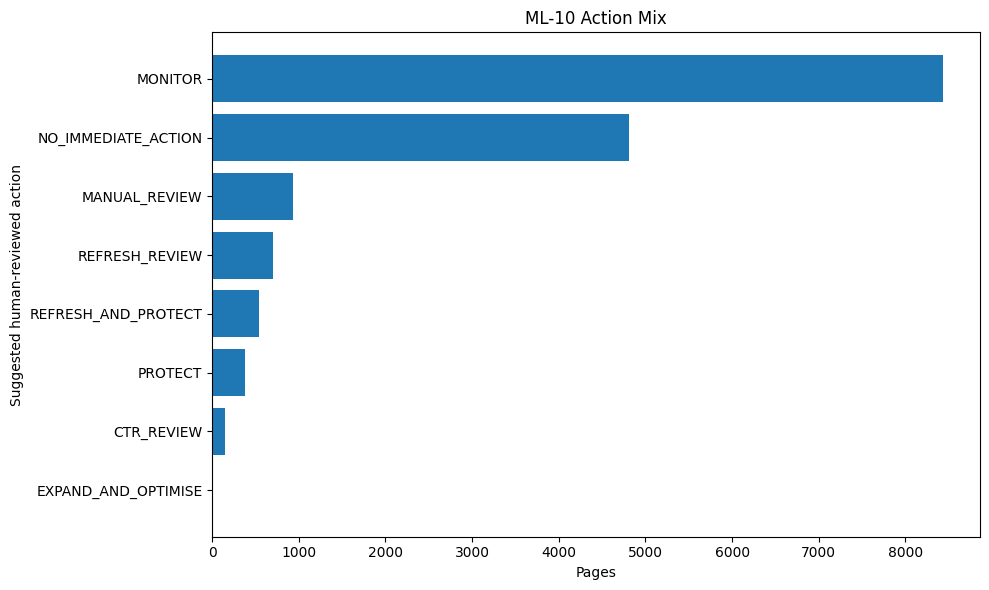

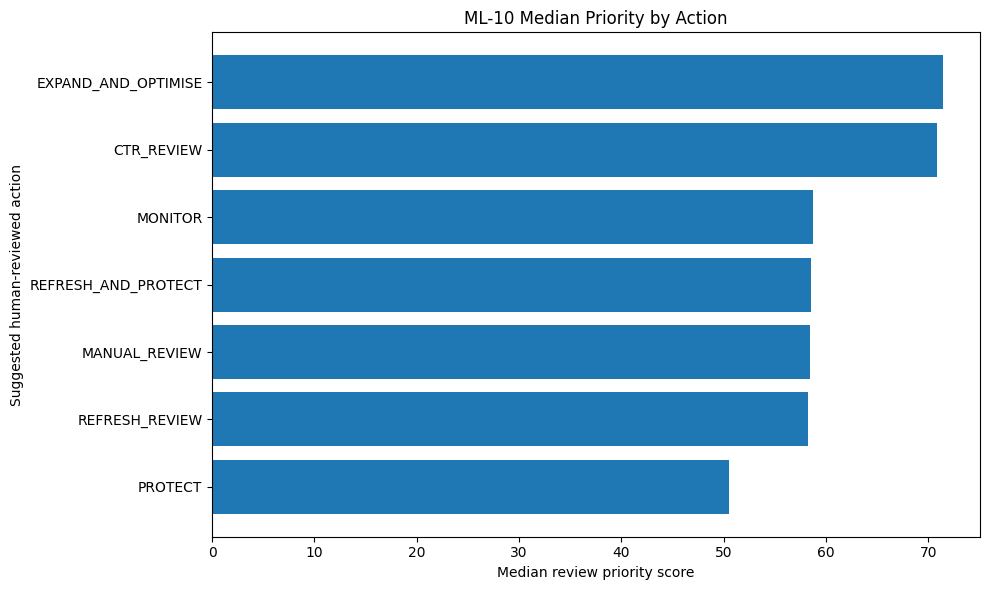

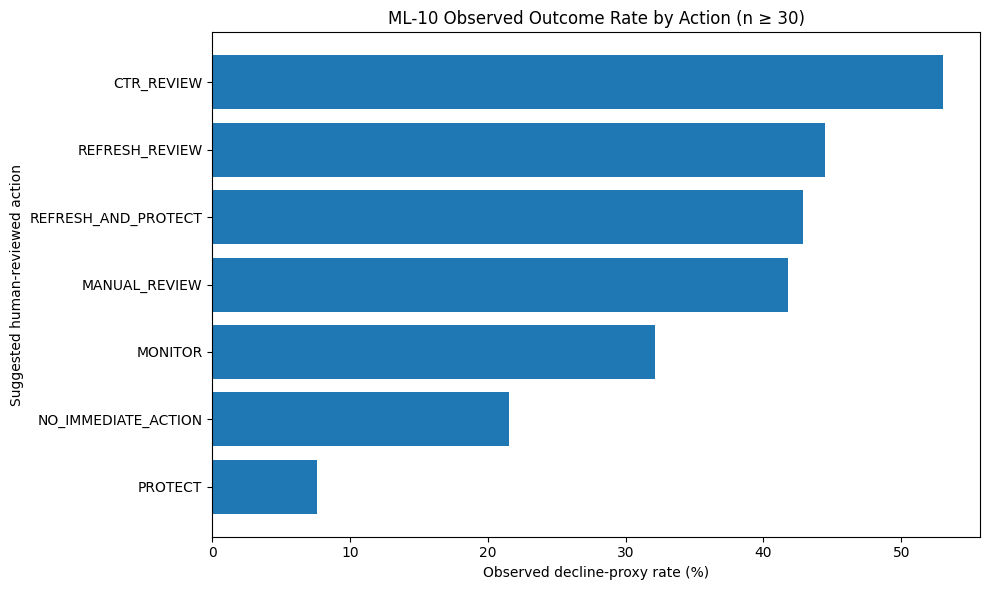

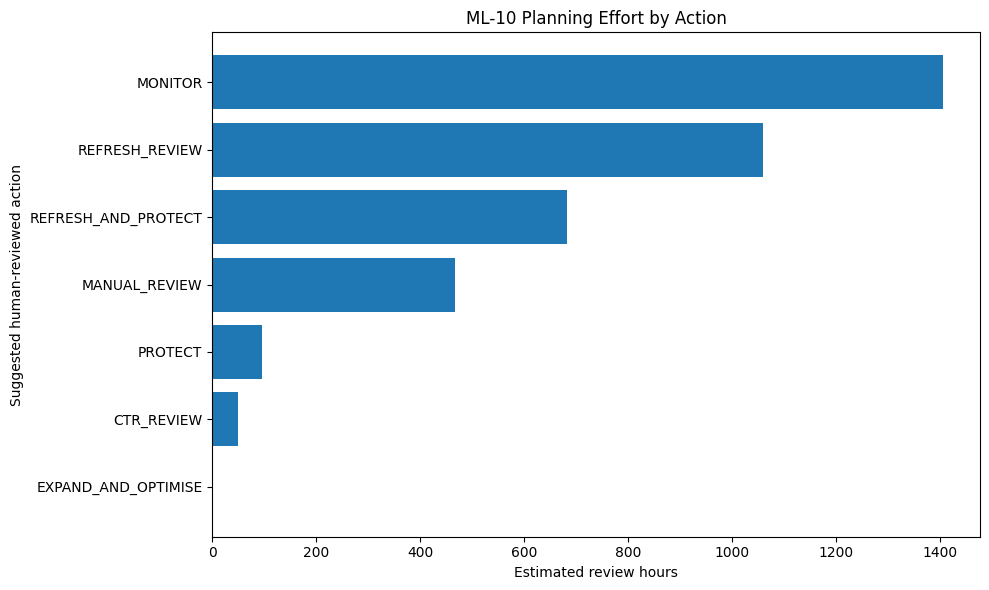

Saved figure: work/figures/ml10_action_mix.png
Saved figure: work/figures/ml10_priority_by_action.png
Saved figure: work/figures/ml10_observed_decline_by_action.png
Saved figure: work/figures/ml10_review_hours_by_action.png


In [14]:
# ============================================================
# REUSABLE PAPER FIGURES
# ============================================================

figure_paths = []


# Figure 1 — action mix
action_mix = (
    full_queue_export[
        "action_label"
    ]
    .value_counts()
    .sort_values(ascending=True)
)

plt.figure(figsize=(10, 6))
plt.barh(
    action_mix.index,
    action_mix.values,
)
plt.xlabel("Pages")
plt.ylabel("Suggested human-reviewed action")
plt.title("ML-10 Action Mix")
plt.tight_layout()

action_mix_path = (
    FIGURE_DIR
    / "ml10_action_mix.png"
)

plt.savefig(
    action_mix_path,
    dpi=180,
    bbox_inches="tight",
)
plt.show()

figure_paths.append(action_mix_path)


# Figure 2 — median priority
priority_by_action = (
    actionable_queue_export
    .groupby(
        "action_label",
        observed=True,
    )["review_priority_score"]
    .median()
    .sort_values(ascending=True)
)

plt.figure(figsize=(10, 6))
plt.barh(
    priority_by_action.index,
    priority_by_action.values,
)
plt.xlabel("Median review priority score")
plt.ylabel("Suggested human-reviewed action")
plt.title("ML-10 Median Priority by Action")
plt.tight_layout()

priority_figure_path = (
    FIGURE_DIR
    / "ml10_priority_by_action.png"
)

plt.savefig(
    priority_figure_path,
    dpi=180,
    bbox_inches="tight",
)
plt.show()

figure_paths.append(priority_figure_path)


# Figure 3 — observed decline by action, adequate n only
decline_for_figure = (
    action_validation[
        action_validation["n"] >= MIN_ARCHETYPE_N
    ]
    .copy()
    .sort_values(
        "observed_decline_rate_pct",
        ascending=True,
    )
)

plt.figure(figsize=(10, 6))
plt.barh(
    decline_for_figure["action_label"],
    decline_for_figure[
        "observed_decline_rate_pct"
    ],
)
plt.xlabel("Observed decline-proxy rate (%)")
plt.ylabel("Suggested human-reviewed action")
plt.title(
    "ML-10 Observed Outcome Rate by Action "
    f"(n ≥ {MIN_ARCHETYPE_N})"
)
plt.tight_layout()

decline_figure_path = (
    FIGURE_DIR
    / "ml10_observed_decline_by_action.png"
)

plt.savefig(
    decline_figure_path,
    dpi=180,
    bbox_inches="tight",
)
plt.show()

figure_paths.append(decline_figure_path)


# Figure 4 — estimated review hours
review_hours_by_action = (
    capacity_summary
    .sort_values(
        "estimated_review_hours",
        ascending=True,
    )
)

plt.figure(figsize=(10, 6))
plt.barh(
    review_hours_by_action["action_label"],
    review_hours_by_action[
        "estimated_review_hours"
    ],
)
plt.xlabel("Estimated review hours")
plt.ylabel("Suggested human-reviewed action")
plt.title(
    "ML-10 Planning Effort by Action"
)
plt.tight_layout()

review_hours_figure_path = (
    FIGURE_DIR
    / "ml10_review_hours_by_action.png"
)

plt.savefig(
    review_hours_figure_path,
    dpi=180,
    bbox_inches="tight",
)
plt.show()

figure_paths.append(
    review_hours_figure_path
)

for figure_path in figure_paths:
    print("Saved figure:", figure_path)

## Results Summary

On the retained grouped-client holdout, the reconstructed Logistic Regression model reports its measured Precision@50, Average Precision, ROC-AUC, and base rate.

The playbook then converts the model output into transparent archetypes and human-reviewed actions using training-referenced thresholds.

The queue is useful for review ordering, not automatic decision-making.

Action-group outcome rates are retrospective descriptions. They do not estimate the causal effect of performing an action.

Review-time estimates and visibility tiers are planning proxies. They are not measured labour costs, revenue forecasts, or monetary ROI.

## Self-check

Before submission, this notebook confirms that:

- the ML-09 split configuration is retained;
- grouped client overlap is zero;
- the validated seven-feature model is reconstructed;
- action thresholds and percentiles are training-referenced;
- action assignment uses no outcome, label, product flag, identifier, or private field;
- the full and actionable queues are ranked and exported;
- reason codes, action labels, confidence notes, cost tiers, and value tiers are populated;
- the decay/refresh insight is framed as observational;
- intended use and limitations are explicit;
- human-review and no-go rules exist;
- monitoring and retrain triggers exist;
- small action groups are not used for headline claims;
- no monetary, causal, automatic-action, or automatic-retraining claim is made;
- required CSVs, JSON receipts, the fitted model, and figures exist;
- the notebook runs top to bottom without errors.

In [15]:
# ============================================================
# EXECUTABLE SELF-CHECK
# ============================================================

required_full_queue_columns = {
    "rank",
    "review_priority_score",
    "model_score",
    "action_label",
    "reason_code",
    "archetype",
    "confidence_level",
    "value_tier",
    "review_cost_tier",
    "estimated_review_minutes",
    "human_review_required",
}

required_actionable_columns = {
    "actionable_rank",
    "review_batch",
    "review_priority_score",
    "action_label",
    "reason_code",
}

required_export_files = [
    FULL_QUEUE_PATH,
    ACTIONABLE_QUEUE_PATH,
    TOP_50_PATH,
    ACTION_VALIDATION_PATH,
    CAPACITY_PATH,
    CAPACITY_SCENARIOS_PATH,
    METRICS_PATH,
    PLAYBOOK_PATH,
    MONITORING_PATH,
    HUMAN_REVIEW_PATH,
    MODEL_PATH,
    *figure_paths,
]

public_display_columns = set(
    public_queue_columns
)

privacy_patterns = [
    "url",
    "domain",
    "raw_query",
    "query_text",
    "client_name",
    "email",
    "token",
]

public_privacy_risks = sorted(
    column
    for column in public_display_columns
    if any(
        pattern in column.lower()
        for pattern in privacy_patterns
    )
)

self_checks = {
    "Split matches ML-09": (
        SEED == 42
        and
        TEST_SIZE == 0.25
    ),
    "Modeling frame is non-empty": (
        len(model_frame) > 0
    ),
    "Seven validated features are used": (
        len(feature_columns) == 7
    ),
    "Grouped client overlap is zero": (
        client_overlap == 0
    ),
    "Prediction count matches validation": (
        len(validation_scores)
        ==
        len(validation_frame)
    ),
    "Model scores are finite": (
        np.isfinite(validation_scores).all()
    ),
    "Precision@50 is valid": (
        0.0
        <= grouped_precision_50
        <= 1.0
    ),
    "Policy references use training rows": (
        policy_reference_receipt.loc[
            0,
            "reference_population",
        ]
        ==
        "training only"
    ),
    "Action inputs exclude forbidden fields": (
        ACTION_INPUT_COLUMNS.isdisjoint(
            FORBIDDEN_ACTION_INPUTS
        )
    ),
    "Full queue covers validation rows": (
        len(full_queue_export)
        ==
        len(validation_frame)
    ),
    "Full queue has required columns": (
        required_full_queue_columns.issubset(
            full_queue_export.columns
        )
    ),
    "Actionable queue has required columns": (
        required_actionable_columns.issubset(
            actionable_queue_export.columns
        )
    ),
    "Full ranks are sequential": (
        full_queue_export["rank"].tolist()
        ==
        list(
            range(
                1,
                len(full_queue_export) + 1,
            )
        )
    ),
    "Actionable ranks are sequential": (
        actionable_queue_export[
            "actionable_rank"
        ].tolist()
        ==
        list(
            range(
                1,
                len(actionable_queue_export) + 1,
            )
        )
    ),
    "Full queue is sorted by priority": (
        full_queue_export[
            "review_priority_score"
        ].is_monotonic_decreasing
    ),
    "Actionable queue is non-empty": (
        len(actionable_queue_export) > 0
    ),
    "Top-50 queue has 50 rows": (
        len(top_50_export) == TOP_K
    ),
    "Reason codes are populated": (
        full_queue_export["reason_code"]
        .astype(str)
        .str.len()
        .gt(0)
        .all()
    ),
    "Action labels are populated": (
        full_queue_export["action_label"]
        .astype(str)
        .str.len()
        .gt(0)
        .all()
    ),
    "Confidence notes are populated": (
        full_queue_export[
            "confidence_note"
        ]
        .astype(str)
        .str.len()
        .gt(0)
        .all()
    ),
    "Actionable rows require review": (
        actionable_queue_export[
            "human_review_required"
        ].eq(True).all()
    ),
    "No-action rows remain in full queue": (
        full_queue_export[
            "action_label"
        ]
        .eq("NO_IMMEDIATE_ACTION")
        .any()
    ),
    "Human-review rules exist": (
        len(human_review_checklist) >= 8
    ),
    "No-go rules exist": (
        len(no_go_list) >= 6
    ),
    "Monitoring triggers exist": (
        len(monitoring_triggers) >= 8
    ),
    "Small action groups are flagged": (
        action_validation.loc[
            action_validation["n"]
            <
            MIN_ARCHETYPE_N,
            "claim_status",
        ]
        .eq(
            "INSUFFICIENT_N_FOR_HEADLINE"
        )
        .all()
    ),
    "Public display excludes privacy-risk fields": (
        len(public_privacy_risks) == 0
    ),
    "No monetary ROI claim": (
        playbook_metrics[
            "monetary_roi_claim"
        ]
        is False
    ),
    "No causal refresh claim": (
        playbook_metrics[
            "causal_refresh_claim"
        ]
        is False
    ),
    "No automatic action": (
        playbook_metrics[
            "automatic_action"
        ]
        is False
    ),
    "No automatic retraining": (
        playbook_metrics[
            "automatic_retraining"
        ]
        is False
    ),
    "Not marked production-ready": (
        playbook_metrics[
            "production_ready"
        ]
        is False
    ),
    "Actual fitted pipeline saved": (
        hasattr(
            playbook_model,
            "predict_proba",
        )
        and
        MODEL_PATH.exists()
    ),
    "All required exports exist": all(
        path.exists()
        for path in required_export_files
    ),
}

self_check_df = pd.DataFrame(
    {
        "check": list(self_checks.keys()),
        "passed": list(self_checks.values()),
    }
)

display(self_check_df)

failed_checks = [
    check_name
    for check_name, passed
    in self_checks.items()
    if not passed
]

if failed_checks:
    raise AssertionError(
        "ML-10 self-check failed: "
        + ", ".join(failed_checks)
    )

print("Saved full queue:", FULL_QUEUE_PATH)
print("Saved actionable queue:", ACTIONABLE_QUEUE_PATH)
print("Saved metrics JSON:", METRICS_PATH)
print("Saved figures:", FIGURE_DIR)
print("All ML-10 self-checks passed.")

,check,passed
0,Split matches ML-09,True
1,Modeling frame is non-empty,True
2,Seven validated features are used,True
3,Grouped client overlap is zero,True
4,Prediction count matches validation,True
5,Model scores are finite,True
6,Precision@50 is valid,True
7,Policy references use training rows,True
8,Action inputs exclude forbidden fields,True
9,Full queue covers validation rows,True


Saved full queue: work/outputs/content_action_playbook_queue.csv
Saved actionable queue: work/outputs/content_action_playbook_actionable_queue.csv
Saved metrics JSON: work/outputs/content_action_playbook_metrics.json
Saved figures: work/figures
All ML-10 self-checks passed.
